In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('cleaned_dataset.csv')
df.head()

C:\Users\mihir\AppData\Local\Temp\ipykernel_19084\795541288.py:1: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('cleaned_dataset.csv')


,asteroid_id,asteroid_name,near_earth_object,potentially_hazardous,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_solution_id,orbit_epoch,...,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,asteroid_class,orbit_fit_rms
0,2000001,1 Ceres,False,False,3.40,939.400,0.0900,0.200,JPL 47,2458600.5,...,4.610000e-09,6.170000e-08,6.620000e-08,7.820000e-09,1.110000e-11,1.200000e-12,3.780000e-08,9.420000e-09,MBA,0.43301
1,2000002,2 Pallas,False,False,4.20,545.000,0.1010,18.000,JPL 37,2459000.5,...,3.470000e-06,6.270000e-06,9.130000e-06,8.860000e-06,4.960000e-09,4.650000e-10,4.080000e-05,3.680000e-06,MBA,0.35936
2,2000003,3 Juno,False,False,5.33,246.596,0.2140,10.594,JPL 112,2459000.5,...,3.220000e-06,1.660000e-05,1.770000e-05,8.110000e-06,4.360000e-09,4.410000e-10,3.530000e-05,3.110000e-06,MBA,0.33848
3,2000004,4 Vesta,False,False,3.00,525.400,0.4228,0.200,JPL 35,2458600.5,...,2.170000e-07,3.880000e-07,1.790000e-07,1.210000e-06,1.650000e-09,2.610000e-10,4.100000e-06,1.270000e-06,MBA,0.39980
4,2000005,5 Astraea,False,False,6.90,106.699,0.2740,3.140,JPL 114,2459000.5,...,2.740000e-06,2.890000e-05,2.980000e-05,8.300000e-06,4.730000e-09,5.520000e-10,3.470000e-05,3.490000e-06,MBA,0.52191


In [3]:
# Check unique values in the column
print("Unique values in 'potentially_hazardous':", df["potentially_hazardous"].unique())
print("Unique values in 'near_earth_object':", df["near_earth_object"].unique())

# Check data types
print(df[["potentially_hazardous", "near_earth_object"]].dtypes)

Unique values in 'potentially_hazardous': [False True 'FALSE' 'N' 'TRUE']
Unique values in 'near_earth_object': [False True 'FALSE' 'TRUE' 'Unknown']
potentially_hazardous    object
near_earth_object        object
dtype: object


In [4]:
# Convert all values to uppercase strings for consistency
df["potentially_hazardous"] = df["potentially_hazardous"].astype(str).str.upper()
df["near_earth_object"] = df["near_earth_object"].astype(str).str.upper()

# Define mappings
hazardous_mapping = {
    "TRUE": 1, 
    "FALSE": 0, 
    "N": 0  # 'N' treated as non-hazardous
}

neo_mapping = {
    "TRUE": 1, 
    "FALSE": 0, 
    "UNKNOWN": 0  # assuming 'Unknown' means not confirmed as NEO
}

# Apply mappings and convert to int
df["potentially_hazardous"] = df["potentially_hazardous"].map(hazardous_mapping).astype(int)
df["near_earth_object"] = df["near_earth_object"].map(neo_mapping).astype(int)

In [5]:
# Check unique values again to confirm proper conversion
print("Unique values in 'potentially_hazardous':", df["potentially_hazardous"].unique())
print("Unique values in 'near_earth_object':", df["near_earth_object"].unique())

Unique values in 'potentially_hazardous': [0 1]
Unique values in 'near_earth_object': [0 1]


In [6]:
df.head()

,asteroid_id,asteroid_name,near_earth_object,potentially_hazardous,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_solution_id,orbit_epoch,...,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,asteroid_class,orbit_fit_rms
0,2000001,1 Ceres,0,0,3.40,939.400,0.0900,0.200,JPL 47,2458600.5,...,4.610000e-09,6.170000e-08,6.620000e-08,7.820000e-09,1.110000e-11,1.200000e-12,3.780000e-08,9.420000e-09,MBA,0.43301
1,2000002,2 Pallas,0,0,4.20,545.000,0.1010,18.000,JPL 37,2459000.5,...,3.470000e-06,6.270000e-06,9.130000e-06,8.860000e-06,4.960000e-09,4.650000e-10,4.080000e-05,3.680000e-06,MBA,0.35936
2,2000003,3 Juno,0,0,5.33,246.596,0.2140,10.594,JPL 112,2459000.5,...,3.220000e-06,1.660000e-05,1.770000e-05,8.110000e-06,4.360000e-09,4.410000e-10,3.530000e-05,3.110000e-06,MBA,0.33848
3,2000004,4 Vesta,0,0,3.00,525.400,0.4228,0.200,JPL 35,2458600.5,...,2.170000e-07,3.880000e-07,1.790000e-07,1.210000e-06,1.650000e-09,2.610000e-10,4.100000e-06,1.270000e-06,MBA,0.39980
4,2000005,5 Astraea,0,0,6.90,106.699,0.2740,3.140,JPL 114,2459000.5,...,2.740000e-06,2.890000e-05,2.980000e-05,8.300000e-06,4.730000e-09,5.520000e-10,3.470000e-05,3.490000e-06,MBA,0.52191


In [7]:
df.dtypes

asteroid_id                               int64
asteroid_name                            object
near_earth_object                         int32
potentially_hazardous                     int32
absolute_magnitude                      float64
diameter_km                             float64
surface_reflectivity                    float64
diameter_uncertainty_km                 float64
orbit_solution_id                        object
orbit_epoch                             float64
orbit_epoch_mjd                           int64
orbit_epoch_calendar                      int64
orbital_eccentricity                    float64
semi_major_axis_au                      float64
perihelion_distance_au                  float64
orbital_inclination_deg                 float64
longitude_ascending_node_deg            float64
argument_perihelion_deg                 float64
mean_anomaly_deg                        float64
aphelion_distance_au                    float64
mean_motion_deg_day                     

In [8]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Drop non-numeric or irrelevant columns
df_model = df.drop(columns=['asteroid_id', 'asteroid_name', 'orbit_solution_id', 'asteroid_class'])


In [9]:
# Separate features (X) and target (y)
X = df_model.drop(columns=['potentially_hazardous'])
y = df_model['potentially_hazardous']

In [10]:
# Perform Train-Test Split (Stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [11]:
# Apply SMOTE only on the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Display shapes to verify
print(f"Original Training Set shape: {X_train.shape}")
print(f"Training Set after SMOTE shape: {X_train_smote.shape}")
print(f"Test Set shape: {X_test.shape}")

Original Training Set shape: (670966, 35)
Training Set after SMOTE shape: (1339040, 35)
Test Set shape: (287558, 35)


# Linear SVM model training and evaluation

In [8]:
# Import necessary libraries
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Subset the training data (for faster modeling)
X_train_sample = X_train_smote.sample(n=20000, random_state=42)
y_train_sample = y_train_smote.loc[X_train_sample.index]

# Train Linear Kernel SVM on subset
linear_svm = SVC(kernel='linear', C=1, random_state=42)
linear_svm.fit(X_train_sample, y_train_sample)

# Predict on test set
y_pred_linear = linear_svm.predict(X_test)

# Confusion Matrix
cm_linear = confusion_matrix(y_test, y_pred_linear)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=linear_svm.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Linear SVM (Subset)')
plt.show()

# Classification Report
print("Classification Report - Linear SVM (Subset)")
print(classification_report(y_test, y_pred_linear))


NameError: name 'X_train_smote' is not defined

In [12]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Keep only selected important features + target
selected_features = [
    'absolute_magnitude',
    'diameter_km',
    'surface_reflectivity',
    'orbital_eccentricity',
    'semi_major_axis_au',
    'perihelion_distance_au',
    'orbital_inclination_deg',
    'earth_moid_au',
    'mean_motion_deg_day',
    'orbit_fit_rms',
    'potentially_hazardous'
]

# Create a new smaller dataframe
df_model = df[selected_features]

# Separate features and labels
X = df_model.drop(columns=['potentially_hazardous'])
y = df_model['potentially_hazardous']

# Train-Test Split (Stratified 70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Display shapes to verify
print(f"Training Set after SMOTE shape: {X_train_smote.shape}")
print(f"Test Set shape: {X_test.shape}")


Training Set after SMOTE shape: (1339040, 10)
Test Set shape: (287558, 10)


In [13]:
# print number of hazardous and non-hazardous asteroids in the training set
print("Number of hazardous asteroids in training set:", y_train_smote.sum())
print("Number of non-hazardous asteroids in training set:", len(y_train_smote) - y_train_smote.sum())

Number of hazardous asteroids in training set: 669520
Number of non-hazardous asteroids in training set: 669520


c:\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


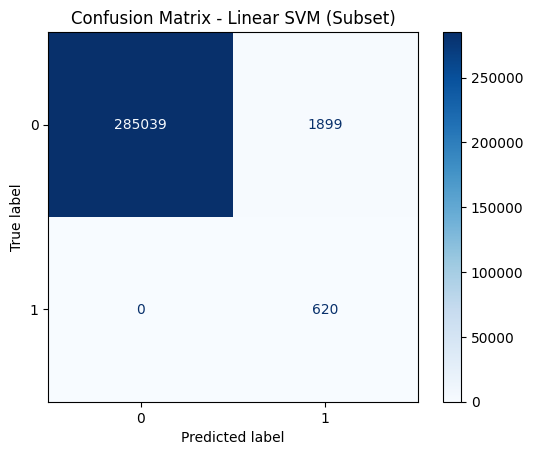

Classification Report - Linear SVM (Subset)
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    286938
           1       0.25      1.00      0.40       620

    accuracy                           0.99    287558
   macro avg       0.62      1.00      0.70    287558
weighted avg       1.00      0.99      1.00    287558



In [14]:
# Import necessary libraries
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Subset the training data (20,000 rows for faster modeling)
X_train_sample = X_train_smote.sample(n=20000, random_state=42)
y_train_sample = y_train_smote.loc[X_train_sample.index]

# Train Linear SVM using LinearSVC
linear_svm = LinearSVC(C=1, random_state=42, max_iter=10000)
linear_svm.fit(X_train_sample, y_train_sample)

# Predict on test set
y_pred_linear = linear_svm.predict(X_test)

# Confusion Matrix
cm_linear = confusion_matrix(y_test, y_pred_linear)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=linear_svm.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Linear SVM (Subset)')
plt.show()

# Classification Report
print("Classification Report - Linear SVM (Subset)")
print(classification_report(y_test, y_pred_linear))


c:\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


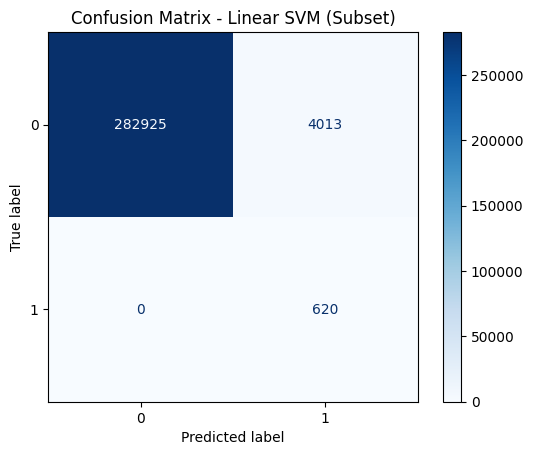

Classification Report - Linear SVM (Subset)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    286938
           1       0.13      1.00      0.24       620

    accuracy                           0.99    287558
   macro avg       0.57      0.99      0.61    287558
weighted avg       1.00      0.99      0.99    287558



In [15]:
# Import necessary libraries
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Subset the training data (20,000 rows for faster modeling)
X_train_sample = X_train_smote.sample(n=20000, random_state=42)
y_train_sample = y_train_smote.loc[X_train_sample.index]

# Train Linear SVM using LinearSVC
linear_svm = LinearSVC(C=0.1, random_state=42, max_iter=10000)
linear_svm.fit(X_train_sample, y_train_sample)

# Predict on test set
y_pred_linear = linear_svm.predict(X_test)

# Confusion Matrix
cm_linear = confusion_matrix(y_test, y_pred_linear)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=linear_svm.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Linear SVM (Subset)')
plt.show()

# Classification Report
print("Classification Report - Linear SVM (Subset)")
print(classification_report(y_test, y_pred_linear))


c:\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


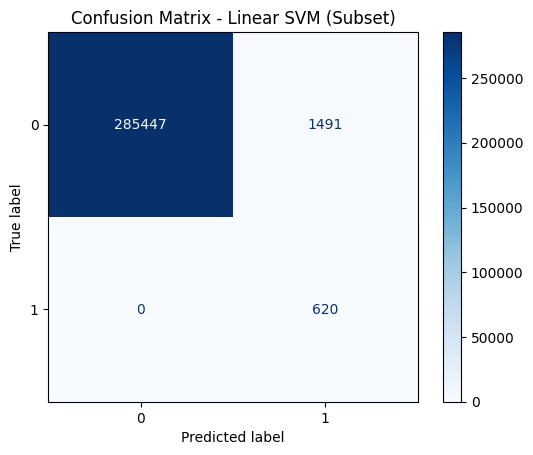

Classification Report - Linear SVM (Subset)
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    286938
           1       0.29      1.00      0.45       620

    accuracy                           0.99    287558
   macro avg       0.65      1.00      0.73    287558
weighted avg       1.00      0.99      1.00    287558



In [16]:
# Import necessary libraries
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Subset the training data (20,000 rows for faster modeling)
X_train_sample = X_train_smote.sample(n=20000, random_state=42)
y_train_sample = y_train_smote.loc[X_train_sample.index]

# Train Linear SVM using LinearSVC
linear_svm = LinearSVC(C=10, random_state=42, max_iter=10000)
linear_svm.fit(X_train_sample, y_train_sample)

# Predict on test set
y_pred_linear = linear_svm.predict(X_test)

# Confusion Matrix
cm_linear = confusion_matrix(y_test, y_pred_linear)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=linear_svm.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Linear SVM (Subset)')
plt.show()

# Classification Report
print("Classification Report - Linear SVM (Subset)")
print(classification_report(y_test, y_pred_linear))


# polynomial svm

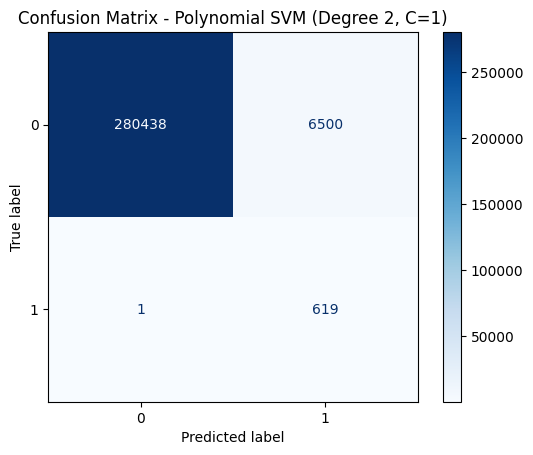

Classification Report - Polynomial SVM (Degree 2, C=1)
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    286938
           1       0.09      1.00      0.16       620

    accuracy                           0.98    287558
   macro avg       0.54      0.99      0.57    287558
weighted avg       1.00      0.98      0.99    287558



In [19]:
# Import necessary libraries
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Subset the training data (10,000 rows for faster modeling)
X_train_sample_poly = X_train_smote.sample(n=10000, random_state=42)
y_train_sample_poly = y_train_smote.loc[X_train_sample_poly.index]

# Train Polynomial Kernel SVM (degree=2)
poly_svm = SVC(kernel='poly', degree=2, C=1, random_state=42)
poly_svm.fit(X_train_sample_poly, y_train_sample_poly)

# Predict on test set
y_pred_poly = poly_svm.predict(X_test)

# Confusion Matrix
cm_poly = confusion_matrix(y_test, y_pred_poly)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_poly, display_labels=poly_svm.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Polynomial SVM (Degree 2, C=1)')
plt.show()

# Classification Report
print("Classification Report - Polynomial SVM (Degree 2, C=1)")
print(classification_report(y_test, y_pred_poly))


# Polynomial SVM (Degree 2, C=0.1)

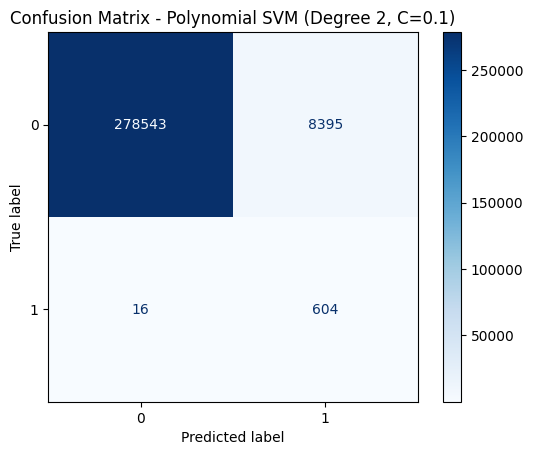

Classification Report - Polynomial SVM (Degree 2, C=0.1)
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    286938
           1       0.07      0.97      0.13       620

    accuracy                           0.97    287558
   macro avg       0.53      0.97      0.56    287558
weighted avg       1.00      0.97      0.98    287558



In [20]:
# Train Polynomial Kernel SVM (degree=2, C=0.1)
poly_svm_c01 = SVC(kernel='poly', degree=2, C=0.1, random_state=42)
poly_svm_c01.fit(X_train_sample_poly, y_train_sample_poly)

# Predict on test set
y_pred_poly_c01 = poly_svm_c01.predict(X_test)

# Confusion Matrix

cm_poly_c01 = confusion_matrix(y_test, y_pred_poly_c01)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_poly_c01, display_labels=poly_svm_c01.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Polynomial SVM (Degree 2, C=0.1)')
plt.show()

# Classification Report
print("Classification Report - Polynomial SVM (Degree 2, C=0.1)")
print(classification_report(y_test, y_pred_poly_c01))


# Polynomial SVM (Degree 2, C=10)

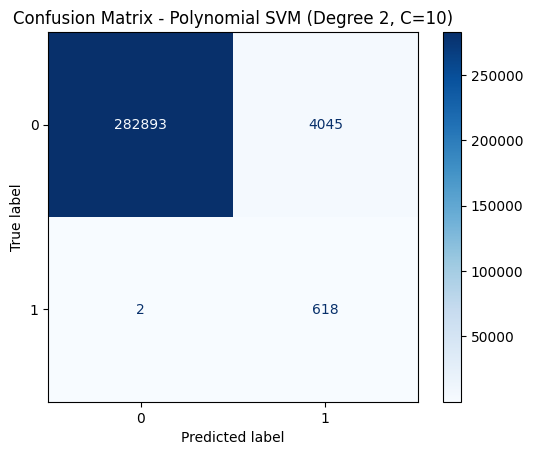

Classification Report - Polynomial SVM (Degree 2, C=10)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    286938
           1       0.13      1.00      0.23       620

    accuracy                           0.99    287558
   macro avg       0.57      0.99      0.61    287558
weighted avg       1.00      0.99      0.99    287558



In [21]:
# Train Polynomial Kernel SVM (degree=2, C=10)
poly_svm_c10 = SVC(kernel='poly', degree=2, C=10, random_state=42)
poly_svm_c10.fit(X_train_sample_poly, y_train_sample_poly)

# Predict on test set
y_pred_poly_c10 = poly_svm_c10.predict(X_test)

# Confusion Matrix
cm_poly_c10 = confusion_matrix(y_test, y_pred_poly_c10)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_poly_c10, display_labels=poly_svm_c10.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Polynomial SVM (Degree 2, C=10)')
plt.show()

# Classification Report
print("Classification Report - Polynomial SVM (Degree 2, C=10)")
print(classification_report(y_test, y_pred_poly_c10))


# visualization

c:\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


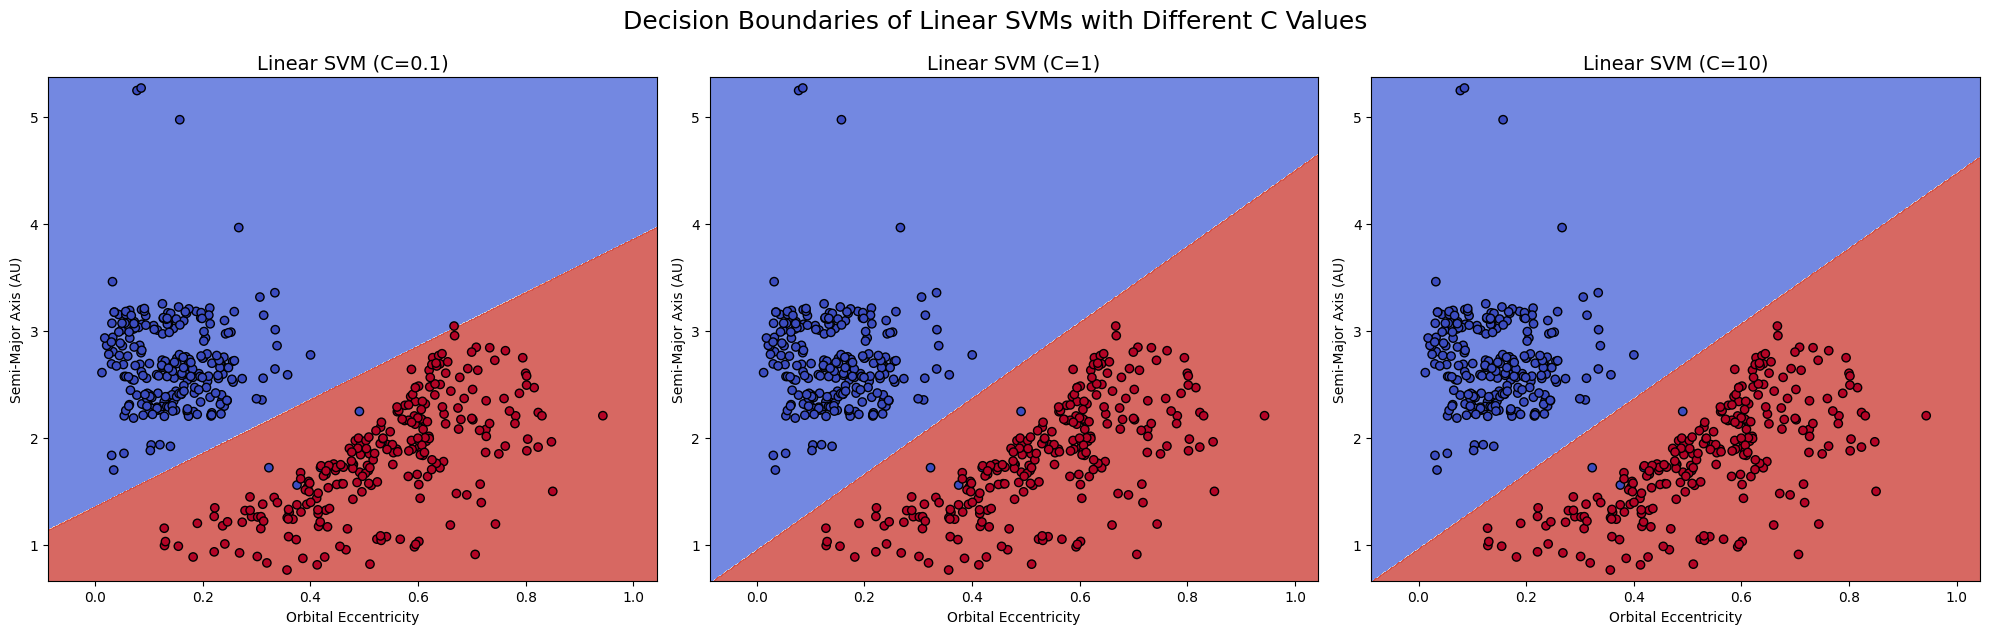

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Define C values
C_values_linear = [0.1, 1, 10]

# Create meshgrid
x_min, x_max = X_vis[selected_features_vis[0]].min() - 0.1, X_vis[selected_features_vis[0]].max() + 0.1
y_min, y_max = X_vis[selected_features_vis[1]].min() - 0.1, X_vis[selected_features_vis[1]].max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Plot settings
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, C in enumerate(C_values_linear):
    linear_svm_vis = SVC(kernel='linear', C=C, random_state=42)
    linear_svm_vis.fit(X_vis, y_vis)

    Z = linear_svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axes[idx].contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    scatter = axes[idx].scatter(X_vis[selected_features_vis[0]], X_vis[selected_features_vis[1]],
                                c=y_vis, edgecolors='k', cmap=plt.cm.coolwarm)

    axes[idx].set_title(f'Linear SVM (C={C})', fontsize=14)
    axes[idx].set_xlabel('Orbital Eccentricity')
    axes[idx].set_ylabel('Semi-Major Axis (AU)')

plt.tight_layout()
plt.suptitle('Decision Boundaries of Linear SVMs with Different C Values', fontsize=18, y=1.05)
plt.show()


In [16]:
# Select two meaningful features for visualization
selected_features_vis = ['orbital_eccentricity', 'semi_major_axis_au']

# Create a smaller subset (500 points)
X_vis = X_train_smote[selected_features_vis].sample(n=500, random_state=42)
y_vis = y_train_smote.loc[X_vis.index]

# Print shape to verify
print(X_vis.shape)



(500, 2)


c:\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


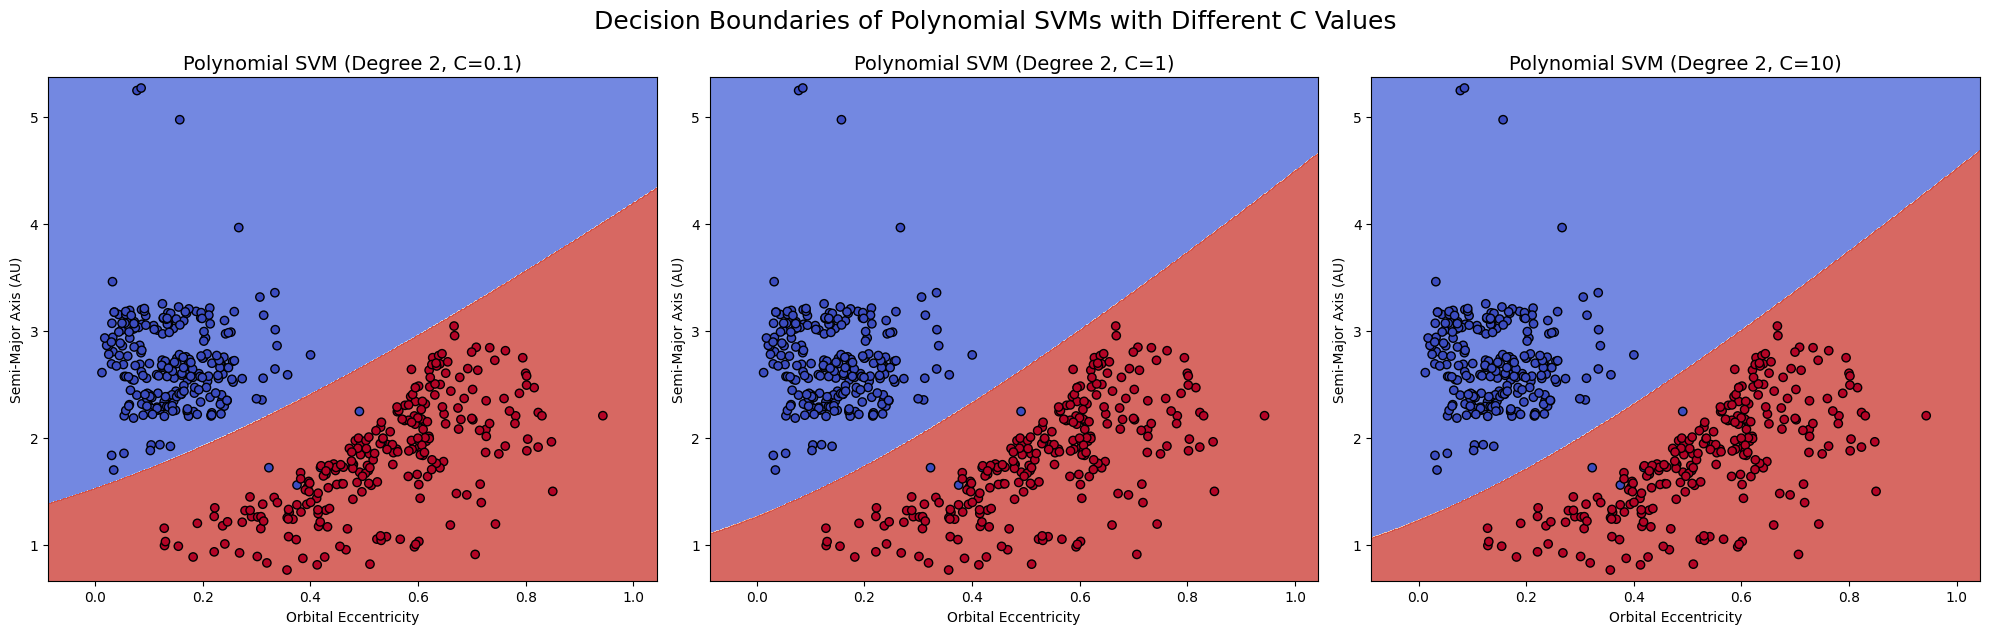

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Define C values to loop through
C_values = [0.1, 1, 10]

# Create meshgrid for plotting decision boundaries
x_min, x_max = X_vis[selected_features_vis[0]].min() - 0.1, X_vis[selected_features_vis[0]].max() + 0.1
y_min, y_max = X_vis[selected_features_vis[1]].min() - 0.1, X_vis[selected_features_vis[1]].max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Plot settings
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, C in enumerate(C_values):
    # Train Polynomial SVM
    poly_svm_vis = SVC(kernel='poly', degree=2, C=C, random_state=42)
    poly_svm_vis.fit(X_vis, y_vis)
    
    # Predict over mesh
    Z = poly_svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    axes[idx].contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    scatter = axes[idx].scatter(X_vis[selected_features_vis[0]], X_vis[selected_features_vis[1]], 
                                c=y_vis, edgecolors='k', cmap=plt.cm.coolwarm)
    
    axes[idx].set_title(f'Polynomial SVM (Degree 2, C={C})', fontsize=14)
    axes[idx].set_xlabel('Orbital Eccentricity')
    axes[idx].set_ylabel('Semi-Major Axis (AU)')

plt.tight_layout()
plt.suptitle('Decision Boundaries of Polynomial SVMs with Different C Values', fontsize=18, y=1.05)
plt.show()



# Train and Plot RBF SVMs (C=0.1, C=1, C=10)




----- RBF SVM with C = 0.1 -----



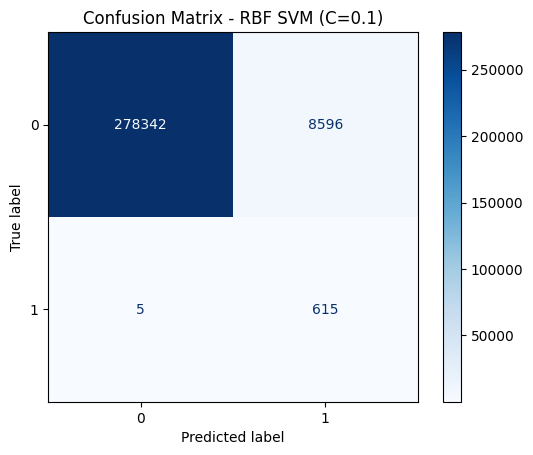

Classification Report - RBF SVM (C=0.1)
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    286938
           1       0.07      0.99      0.13       620

    accuracy                           0.97    287558
   macro avg       0.53      0.98      0.55    287558
weighted avg       1.00      0.97      0.98    287558


----- RBF SVM with C = 1 -----



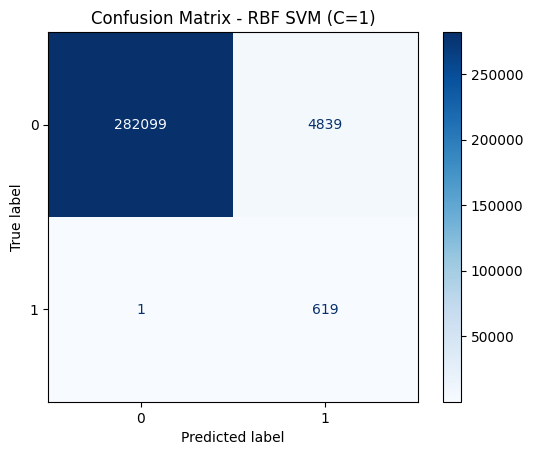

Classification Report - RBF SVM (C=1)
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    286938
           1       0.11      1.00      0.20       620

    accuracy                           0.98    287558
   macro avg       0.56      0.99      0.60    287558
weighted avg       1.00      0.98      0.99    287558


----- RBF SVM with C = 10 -----



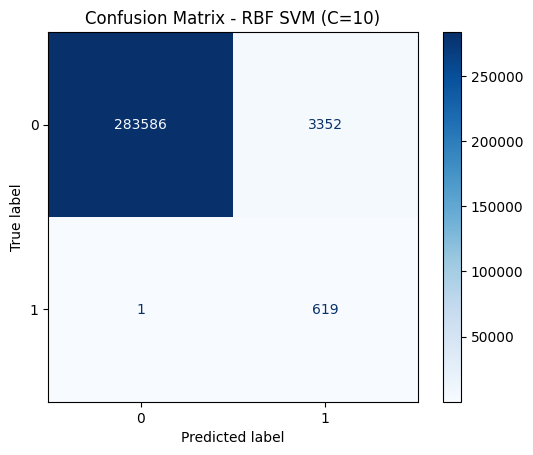

Classification Report - RBF SVM (C=10)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    286938
           1       0.16      1.00      0.27       620

    accuracy                           0.99    287558
   macro avg       0.58      0.99      0.63    287558
weighted avg       1.00      0.99      0.99    287558



In [23]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Subset the training data to 20,000 points
X_train_sample_rbf = X_train_smote.sample(n=20000, random_state=42)
y_train_sample_rbf = y_train_smote.loc[X_train_sample_rbf.index]

# List of C values
C_values_rbf = [0.1, 1, 10]

# Loop through each C value
for C in C_values_rbf:
    print(f"\n----- RBF SVM with C = {C} -----\n")
    
    # Train RBF SVM on sampled training set
    rbf_svm = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    rbf_svm.fit(X_train_sample_rbf, y_train_sample_rbf)
    
    # Predict on full test set
    y_pred_rbf = rbf_svm.predict(X_test)
    
    # Confusion Matrix
    cm_rbf = confusion_matrix(y_test, y_pred_rbf)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=rbf_svm.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - RBF SVM (C={C})')
    plt.show()
    
    # Classification Report
    print(f"Classification Report - RBF SVM (C={C})")
    print(classification_report(y_test, y_pred_rbf))



c:\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


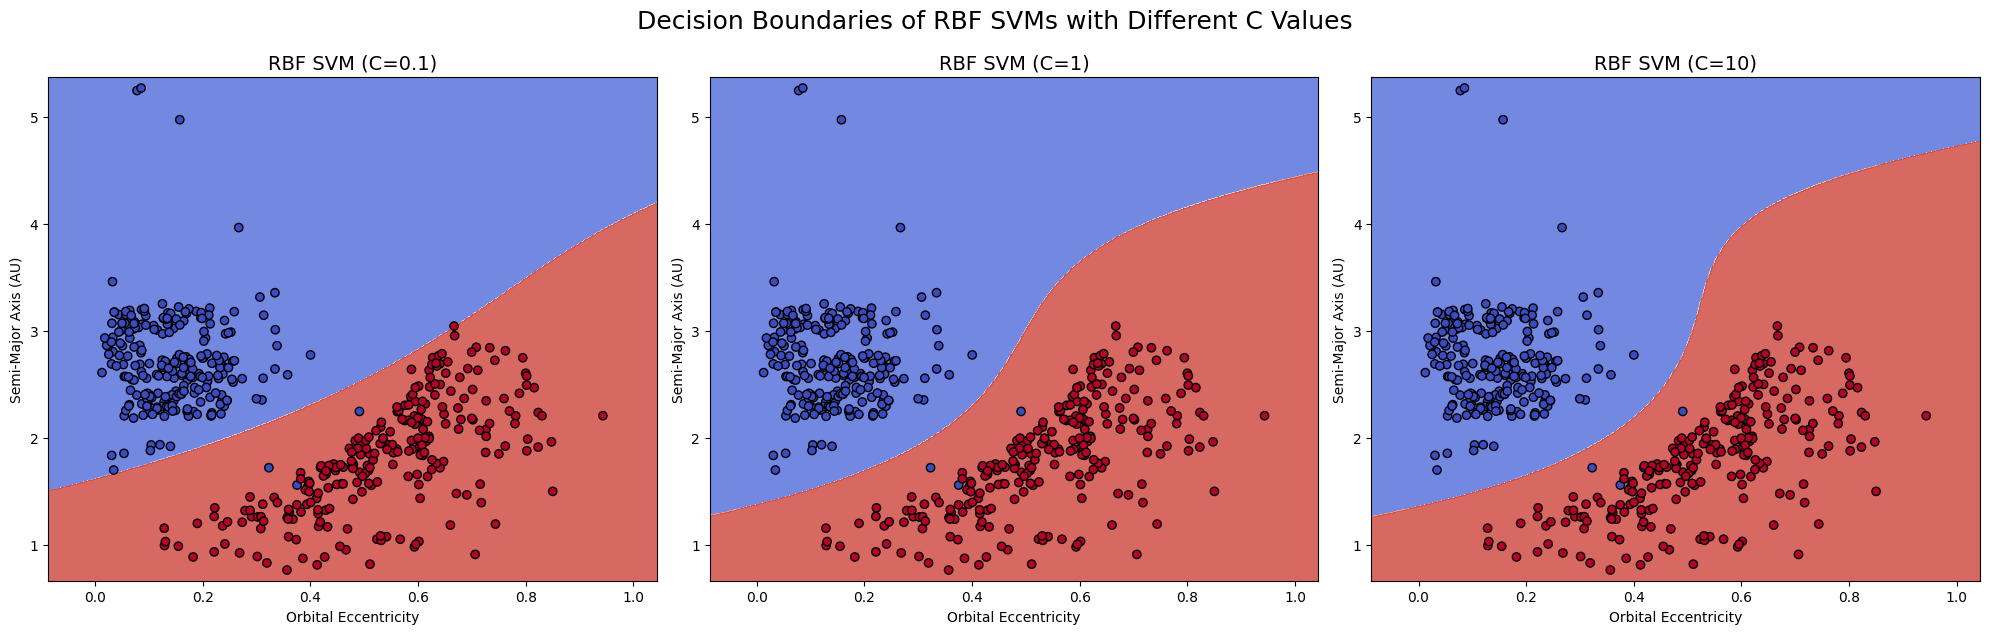

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Reuse small sample: X_vis, y_vis
# (500 points, 2 features)

# C values to loop
C_values_rbf = [0.1, 1, 10]

# Create meshgrid for plotting
x_min, x_max = X_vis[selected_features_vis[0]].min() - 0.1, X_vis[selected_features_vis[0]].max() + 0.1
y_min, y_max = X_vis[selected_features_vis[1]].min() - 0.1, X_vis[selected_features_vis[1]].max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Plotting settings
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, C in enumerate(C_values_rbf):
    # Train RBF SVM
    rbf_svm_vis = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    rbf_svm_vis.fit(X_vis, y_vis)
    
    # Predict mesh
    Z = rbf_svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    axes[idx].contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    scatter = axes[idx].scatter(X_vis[selected_features_vis[0]], X_vis[selected_features_vis[1]],
                                c=y_vis, edgecolors='k', cmap=plt.cm.coolwarm)
    
    axes[idx].set_title(f'RBF SVM (C={C})', fontsize=14)
    axes[idx].set_xlabel('Orbital Eccentricity')
    axes[idx].set_ylabel('Semi-Major Axis (AU)')

plt.tight_layout()
plt.suptitle('Decision Boundaries of RBF SVMs with Different C Values', fontsize=18, y=1.05)
plt.show()


In [25]:
# Choose two features for visualization
selected_features_vis = ['orbital_eccentricity', 'semi_major_axis_au']

# Create a small 2-feature sample (500 rows)
X_vis = X_train_smote[selected_features_vis].sample(n=500, random_state=42)
y_vis = y_train_smote.loc[X_vis.index]
